# Algorytm wyczerpującego przeszukiwania

Znany także jako brute force. Polega na naiwnym policzeniu energi dla każdej konfiguracji i wybraniu optymalnej.  

W kontekście rozwiązywania modelu Isinga/QUBO, warto wykorzystać fakt, że każda liczba naturalna posiada unikatową reprezentację binarną. Przykładowo:

$$
123 = (1111011)_2
$$

Zauważmy, że dowolny ciąg binarny długości $N$ reprezentuje stan Isinga dla $N$ spinów. Wtedy iterując po wszystkich liczbach od 0 do $2^{N}-1$ mamy pewność, że sprawdzilismy wszystkie stany. 

## Implementacja naiwna



In [1]:
# Ustawienie ścierzek dla plików pomocniczych
from setup import setup_paths
setup_paths()

# Implementacja naiwnej pętli
import numpy as np
from math import inf
from tqdm import tqdm
from itertools import product
from funkcje_pomocnicze import calculate_energy

def brute_force_naive_qubo(Q: np.ndarray):
    best_energy = inf
    best_state = None
    n = Q.shape[0]

    def int_to_bits(n: int, width: int, dtype=np.uint8):
        shifts = np.arange(width - 1, -1, -1, dtype=np.uint64)
        return ((np.uint64(n) >> shifts) & 1).astype(dtype)

    for i in tqdm(range(2**n), desc="Wyczerpujące przeszukiwanie"):
        state = int_to_bits(i, n)
        energy = state @ Q @ state.T

        if energy < best_energy:
            best_energy = energy
            best_state = state

    return best_state, best_energy


# używając itertools
def brute_force_naive(J, h):
    best_energy = inf
    best_state = None
    n = len(h)

    for state in tqdm(product([-1, 1], repeat=n), desc="Wyczerpujące przeszukiwanie", total=2**n):
        state = np.array(state)
        energy = calculate_energy(J, h, state, convention="dwave")
        if energy < best_energy:
            best_energy = energy
            best_state = state

    return best_state, best_energy




In [2]:
# Instancja testowa 8 spinów

import time
from funkcje_pomocnicze import ising_to_qubo, read_instance, K8

J, h = read_instance(K8.path, convention="dwave")
Q, offset = ising_to_qubo(J, h)  # instancje testowe są zapisane jako ising

start = time.time()
state, energy = brute_force_naive_qubo(Q)
end = time.time()

print(f"Otrzymana energia: {energy + offset}")
print(f"Stan podstawowy: {K8.best_energy}")
print(f"czas: {end - start}")

Wyczerpujące przeszukiwanie: 100%|██████████| 256/256 [00:00<00:00, 85400.61it/s]

Otrzymana energia: -9.5
Stan podstawowy: -9.5
czas: 0.06356239318847656


In [3]:
# Instancja testowa 8 spinów

import time
from funkcje_pomocnicze import read_instance, K8
J, h = read_instance(K8.path, convention="dwave")  # pamiętamy o odpowiedniej konwencji zapisu instancji

start = time.time()
state, energy = brute_force_naive(J, h)
end = time.time()

print(f"Otrzymana energia: {energy}")
print(f"Stan podstawowy: {K8.best_energy}")
print(f"czas: {end - start}")


Wyczerpujące przeszukiwanie: 100%|██████████| 256/256 [00:00<00:00, 128039.81it/s]

Otrzymana energia: -9.5
Stan podstawowy: -9.5
czas: 0.0039975643157958984


Wyczerpujące przeszukiwanie dla różnych n (może trwać kilka minut): 100%|██████████| 23/23 [03:35<00:00,  9.38s/it]


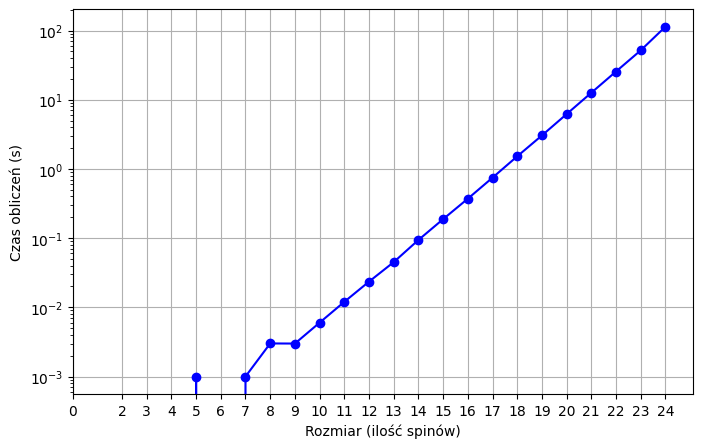

In [4]:
# Polecam zobaczyć jak rozmiar n wpływa na czas obliczeń, dla n>20 czas obliczeń zaczyna rosnąć bardzo szybko
import os
import time
import matplotlib.pyplot as plt
from IPython.utils.io import capture_output

times = []
is_automated_run = "PYTEST_CURRENT_TEST" in os.environ
n_range = list(range(2, 18 if is_automated_run else 25))
for n in tqdm(n_range, desc="Wyczerpujące przeszukiwanie dla różnych n (może trwać kilka minut)"):

    J = np.triu(np.random.uniform(-1, 1, size=(n, n)), k=1)  # losowa gęsta macierz górnotrójkątna
    h = np.random.uniform(-1, 1, size=n)  # losowy wektor
    start = time.time()
    with capture_output() as captured:
        state, energy = brute_force_naive(J, h)
    end = time.time()
    elapsed = end - start
    times.append(elapsed)

plt.figure(figsize=(8, 5))
plt.plot(n_range, times, marker='o', linestyle='-', color='blue', label='Execution Time')
plt.xlabel('Rozmiar (ilość spinów)')
plt.xticks([0] + n_range)
plt.yscale('log', base=10)
plt.ylabel('Czas obliczeń (s)')
plt.grid(True)
plt.show()



Złożonośc obliczeniowa tego algorytmu rośnie wykładniczo.

## Efektywne implementacje

Istnieją dużo efektywniejsze implementacje tego algorytmu wykorzystujące GPU. Przykłaem jest oprogramowanie [Omnisolver-bruteforce](https://github.com/euro-hpc-pl/omnisolver-bruteforce). Poniżej jest link do dokumentu pokazującego wyniki benchmarków.

[wykres](../Dzien_2/benchmarks/wyniki.ipynb#wyczerpujące-przeszukiwanie)


# Bibliografia

* Jałowiecki, K., Rams, M. M., & Gardas, B. (2021). Brute-forcing spin-glass problems with CUDA. *Computer Physics Communications*, *260*, 107728. DOI: [10.1016/j.cpc.2020.107728](https://doi.org/10.1016/j.cpc.2020.107728)

* Jałowiecki, K., & Pawela, Ł. (2023). Omnisolver: An extensible interface to Ising spin–glass and QUBO solvers. *SoftwareX*, *24*, 101559. DOI: [10.1016/j.softx.2023.101559](https://doi.org/10.1016/j.softx.2023.101559)
